In [60]:
import pandas as pd
import json
import numpy as np
import multiprocessing as mp
import seaborn as sns
import matplotlib.pyplot as plt
from catomatic.BinaryCatalogue import BinaryBuilder
import pathlib
import matplotlib.cm as cm
import ast

from protocols import utils, functions, graphs

plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Helvetica'  
plt.rcParams['figure.figsize'] = (6.69, 5.02)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Run grid search on the Entire dataset (training + validation)

We want to release a catalogue built on the entire dataset, and therefore need to run a gridsearch also on the entire dataset.

Code mostly the same as `02-grid-search.ipynb`

Uses multiprocessing implemented for Unix/MacOS, and may need to be adapted for Windows.

In [61]:
# the path to the CRyPTIC v3.1.0 data tables (including the DST_MEASUREMENTS_+.pkl which has DST for the validation samples appended)
cryptic_tables_path = 'data/cryptic-tables-v3.4.0/'

#read in genes relevant to each drug
with open('data/drug_to_genes.json', 'r') as f:
    drug_genes = json.load(f)

# whether to run the processes which take a long time
run_long_processes = False

# number of cores
n_cores = 9

In [62]:

def process_grid_search(args):
    '''
    Process one combination of drug, background, and p-value
    '''

    drug, genes, mutations_dir, phenotypes_path, samples_path, mut_path, var_path, catfile_dir, FRS, background, p, geno_version, pheno_version = args

    results = {}

    mutations = functions.prep_mutations(mutations_dir, genes, version=geno_version, mut_path=mut_path, var_path=var_path, train=True)
    
    test_mutations = functions.prep_mutations(mutations_dir, genes, version=geno_version, mut_path=mut_path, var_path=var_path, train=False)
    
    train_phenotypes = functions.prep_phenotypes(drug, phenotypes_path,  samples_path , version=pheno_version, validation=False)
    val_phenotypes = functions.prep_phenotypes(drug, phenotypes_path, samples_path , version=pheno_version, validation=True)
    
    #combine training and validation samples into one dataset
    phenotypes = pd.concat([train_phenotypes, val_phenotypes])

    catfile = f"{catfile_dir}/{drug.lower()}/bg_{background}_p_{p}_FRS_{np.round(FRS,1)}.csv"
    
    #if not os.path.exists(catfile):
    catalogue = BinaryBuilder(samples=phenotypes, mutations=mutations, FRS=FRS, seed=drug_genes[drug]['phylogenetic']).build(test='Binomial', background=background, strict_unlock=True, p=p)
    
    catalogue.to_piezo(genbank_ref='NC00962.3', catalogue_name=f'{drug}-{background}-{p}', version='0.0', 
                        drug=drug, wildcards=f"./data/wildcards/{drug.lower()}_wildcards.json", json_dumps=True, outfile=catfile)

    all_data = pd.merge(phenotypes, test_mutations[test_mutations.FRS >= 0.1], on=['UNIQUEID'], how='left')
    
    cmx, dpr, sens, spec, sens2, spec2 = functions.piezo_predict(iso_df=all_data, drug=drug, catalogue_file=catfile)
    
    results[(drug, background, p)] = {"cm": cmx, "dpr": dpr, "sens": sens, "spec": spec, "sens2": sens2, "spec2": spec2}
    
    return results


def parallel_grid_search(mutations_dir, phenotypes_path,  samples_path, mut_path, var_path, catfile_dir, FRS, geno_version, pheno_version, cores):
    '''
    Main function for parallel execution
    '''

    grid_results = {}
    
    # Create list of tasks to parallelize
    tasks = []
    
    for drug, data in drug_genes.items():

        genes = data['genes']

        for background in [0.05, 0.10, 0.15, 0.20, 0.25]:
            for p in [0.9, 0.95]: #PWF: only one p-value for now, removed 0.95
        
                tasks.append((drug, genes, mutations_dir, phenotypes_path, samples_path, mut_path, var_path, catfile_dir, FRS, background, p, geno_version, pheno_version))

    ctx = mp.get_context("fork")  
    num_workers = min(cores, len(tasks))
    
    with ctx.Pool(num_workers) as pool:
        all_results = pool.map(process_grid_search, tasks)  # Run in parallel

    for result in all_results:
        grid_results.update(result)
    return grid_results


In [63]:
#best to run with 1 core when first run, as the memory requirements are steep 
# when first processing the mutations tables (thereafter they are automatically read in)

if run_long_processes:

   # run grid search on crypticv1 samples
   grid_results = parallel_grid_search(
      "data/mutations-v3.4.0/",
      cryptic_tables_path+"DST_MEASUREMENTS.parquet",
      cryptic_tables_path+"WGS_SAMPLES.parquet",
      cryptic_tables_path+"MUTATIONS.parquet",
      cryptic_tables_path+"VARIANTS.parquet",
      "catalogues/MTBC-CRyPTICv3.4.0-2025.8/grid_search",
      0.1, #FRS
      'v3.4.0', #genome table version
      'v3.4.0', #phenotype table version
      cores=n_cores
   )

   df = utils.flatten_grid_results(grid_results)

   df.to_csv('results/grid_search/MTBC-CRyPTICv3.4.0-2025.8_grid_results.csv')

else: 
   
   df = pd.read_csv('results/grid_search/MTBC-CRyPTICv3.4.0-2025.8_grid_results.csv')

df[:10]

,Unnamed: 0,DRUG,BACKGROUND_RATE,conf_level,SENSITIVITY,SPECIFICITY,DPR,SENSITIVITY2,SPECIFICITY2
0,0,RIF,0.05,0.90,0.960841,0.976607,0.971896,0.958188,0.977535
1,1,RIF,0.05,0.95,0.960833,0.976605,0.969131,0.957991,0.977625
2,2,RIF,0.10,0.90,0.960703,0.976846,0.974579,0.956282,0.977655
3,3,RIF,0.10,0.95,0.960756,0.976900,0.973340,0.956019,0.977746
4,4,RIF,0.15,0.90,0.960058,0.977157,0.980996,0.956019,0.977746
5,5,RIF,0.15,0.95,0.960053,0.977135,0.979407,0.955887,0.977776
6,6,RIF,0.20,0.90,0.960053,0.977227,0.982089,0.955887,0.977776
7,7,RIF,0.20,0.95,0.959883,0.979273,0.978190,0.951680,0.979851
8,8,RIF,0.25,0.90,0.959516,0.983928,0.974702,0.942673,0.984392
9,9,RIF,0.25,0.95,0.959453,0.983989,0.972866,0.941161,0.984482


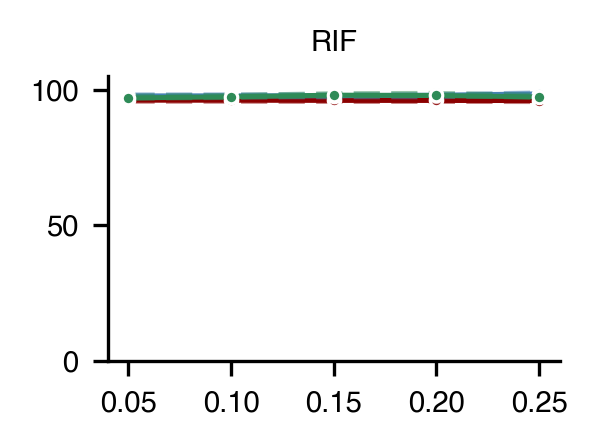

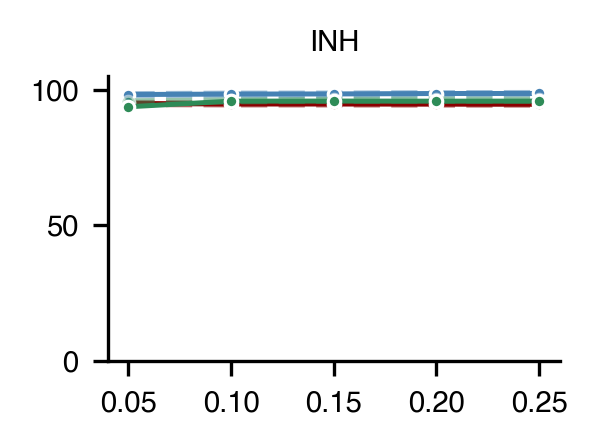

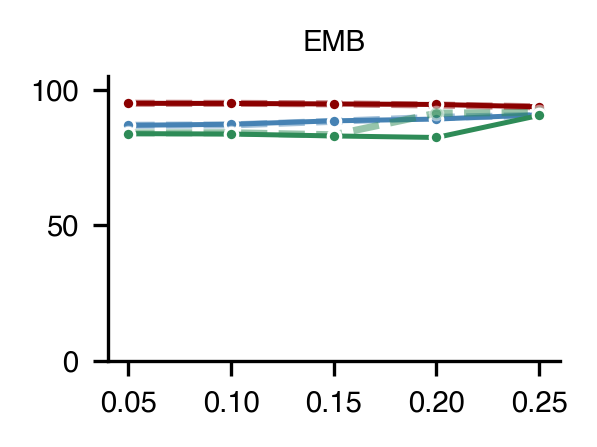

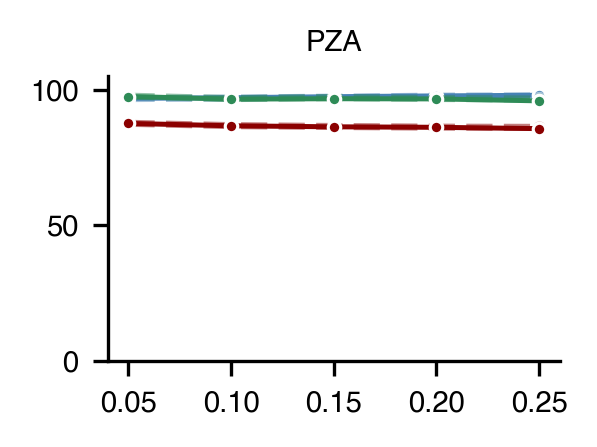

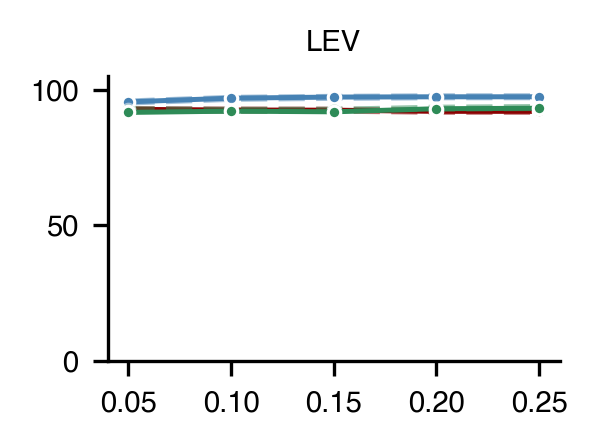

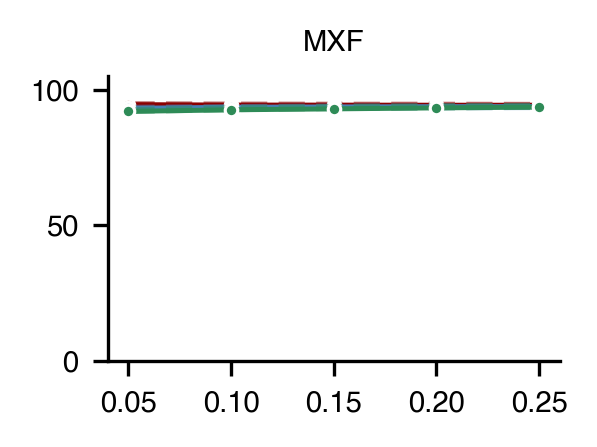

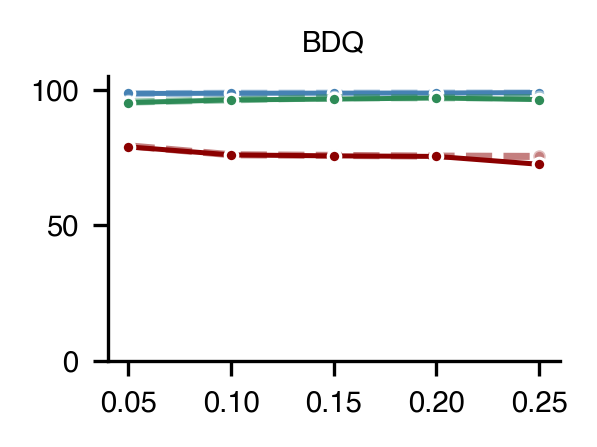

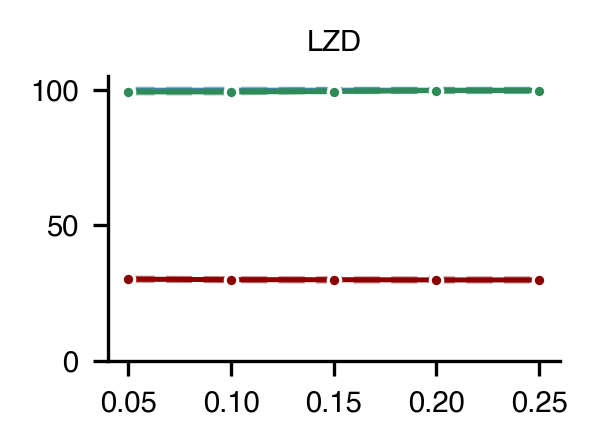

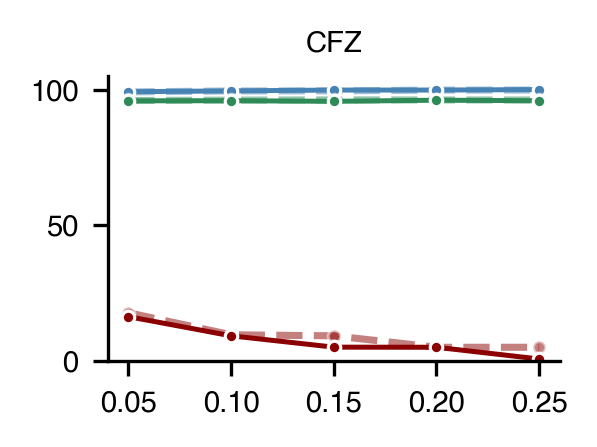

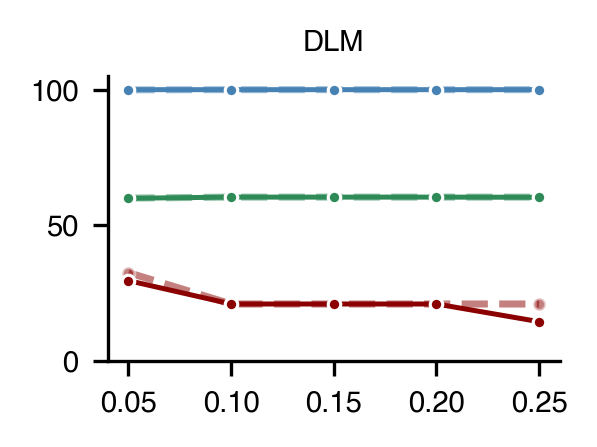

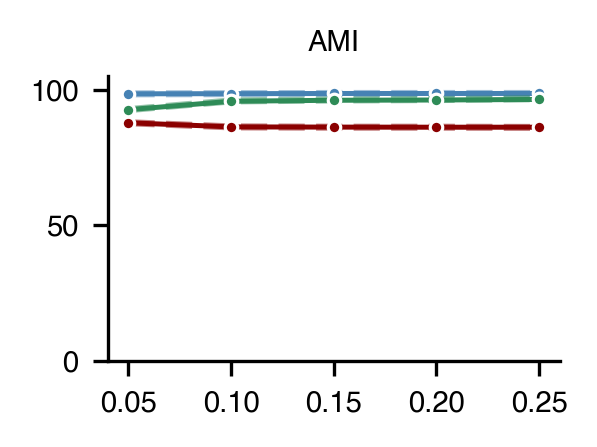

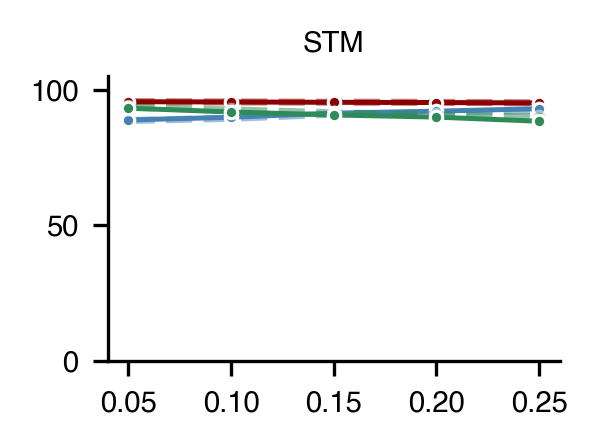

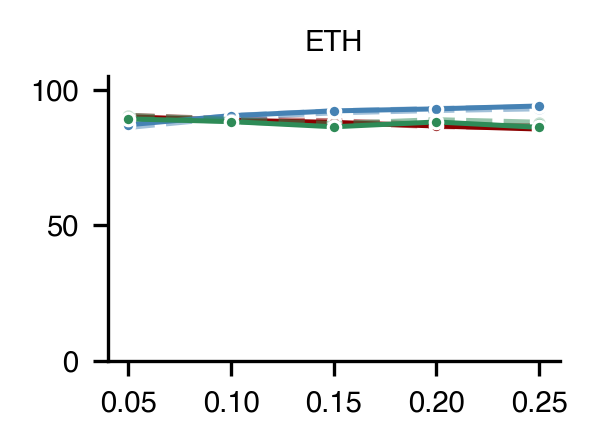

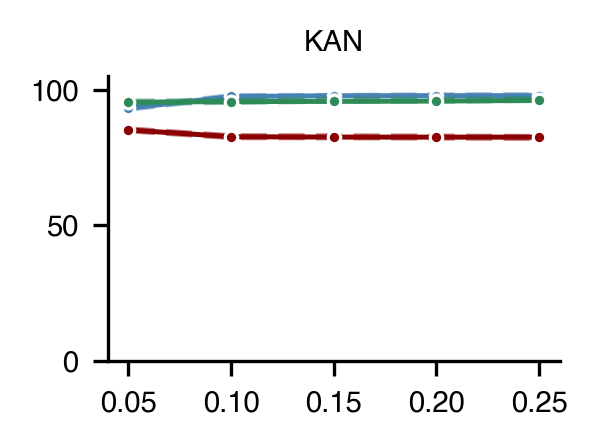

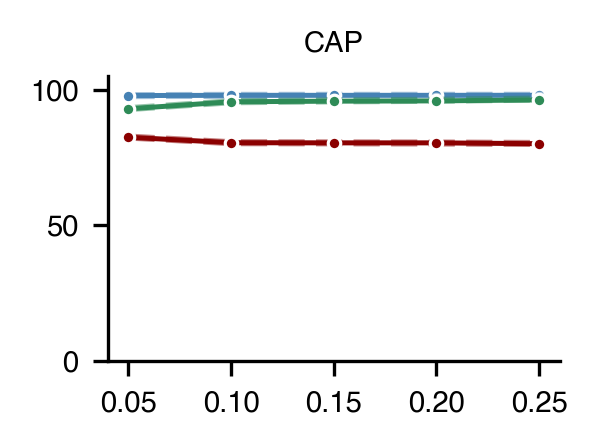

In [64]:
# Melt the DataFrame for plotting
melted_df = df.melt(
    id_vars=["DRUG", "BACKGROUND_RATE", "conf_level"],
    value_vars=["SENSITIVITY", "SPECIFICITY", "DPR"],
    var_name="Metric",
    value_name="Value",
)

melted_df['value'] = 100* melted_df['Value']
melted_df.drop(columns=['Value'], inplace=True)

graphs.grid_search_plots(melted_df)

# Use weighted score to choose best performing catalogue

We now choose a set of parameters for each drug. 

An arbitrarily weighted cost function to balance sensitivity, specificity, and DPR is sufficient for this task.

In [ ]:

# Step 1: Select the best performing catalogue for each DRUG
opt_cats = functions.weighted_score(df).groupby("DRUG").head(1).reset_index(drop=True)

# Step 2: Pull out R, S, U counts from each filtered catalogue
cat_counts = pd.DataFrame([
    {
        "DRUG": opt_cats['DRUG'][i],
        "R": filtered_cat["PREDICTION"].value_counts().get("R", 0),
        "S": filtered_cat["PREDICTION"].value_counts().get("S", 0),
        "U": filtered_cat["PREDICTION"].value_counts().get("U", 0),
        "Total": len(filtered_cat)
    }
    for i in opt_cats.index
    for cat in [pd.read_csv(
        f"./catalogues/MTBC-CRyPTICv3.4.0-2025.8/grid_search/"
        f"{opt_cats['DRUG'][i].lower()}/"
        f"bg_{opt_cats['BACKGROUND_RATE'][i]}_p_{opt_cats['conf_level'][i]}_FRS_0.1.csv"
    )]
    for filtered_cat in [cat[cat['EVIDENCE'].apply(lambda x: ast.literal_eval(x) != {"default_rule": "True"})]]
])

# Step 3: Merge and export
opt_cats = pd.merge(opt_cats, cat_counts, on='DRUG')
opt_cats['catalogue'] = 'MTBC-CRyPTICv3.4.0-2025.8'
opt_cats.to_csv('results/grid_search/opt_cats_MTBC-CRyPTICv3.4.0-2025.8.csv', index=False)
opt_cats


,Unnamed: 0,DRUG,BACKGROUND_RATE,conf_level,SENSITIVITY,SPECIFICITY,DPR,SENSITIVITY2,SPECIFICITY2,Score,R,S,U,Total,catalogue
0,6,RIF,0.20,0.9,0.960053,0.977227,0.982089,0.955887,0.977776,0.968754,49,19,393,461,MTBC-CRyPTICv3.4.0-2025.8
1,16,INH,0.20,0.9,0.946292,0.985017,0.961145,0.926351,0.985769,0.958944,86,22,714,822,MTBC-CRyPTICv3.4.0-2025.8
2,58,MXF,0.25,0.9,0.941687,0.937332,0.938199,0.910808,0.941539,0.939901,12,32,611,655,MTBC-CRyPTICv3.4.0-2025.8
3,44,LEV,0.15,0.9,0.924278,0.971289,0.923522,0.890895,0.973730,0.935880,17,15,381,413,MTBC-CRyPTICv3.4.0-2025.8
4,114,STM,0.15,0.9,0.953480,0.909160,0.914384,0.903127,0.918497,0.934581,135,9,613,757,MTBC-CRyPTICv3.4.0-2025.8
5,26,EMB,0.20,0.9,0.943092,0.897554,0.912953,0.896798,0.907336,0.925680,23,45,1164,1232,MTBC-CRyPTICv3.4.0-2025.8
6,30,PZA,0.05,0.9,0.875633,0.966762,0.975638,0.866854,0.967671,0.918416,554,0,165,719,MTBC-CRyPTICv3.4.0-2025.8
7,100,AMI,0.05,0.9,0.877747,0.984234,0.926044,0.856186,0.985470,0.914028,10,6,470,486,MTBC-CRyPTICv3.4.0-2025.8
8,120,ETH,0.05,0.9,0.901389,0.863995,0.900786,0.823604,0.877938,0.891920,357,0,402,759,MTBC-CRyPTICv3.4.0-2025.8
9,130,KAN,0.05,0.9,0.851510,0.930699,0.953812,0.846996,0.934243,0.891768,25,4,457,486,MTBC-CRyPTICv3.4.0-2025.8


In [66]:
print('Total number of non-U rows:', opt_cats[['R', 'S']].to_numpy().sum())

Total number of non-U rows: 1709


In [68]:
rows = []

opt_cats = pd.read_csv('results/grid_search/opt_cats_MTBC-CRyPTICv1.1.1-2025.8.csv')

for idx,row in opt_cats.iterrows():
    cat_path = pathlib.Path( "./catalogues/MTBC-CRyPTICv3.4.0-2025.8/grid_search/") 
    cat =  cat_path / row.DRUG.lower() / f"bg_{row.BACKGROUND_RATE}_p_{row.conf_level}_FRS_0.1.csv"
    if cat.is_file():
        df = pd.read_csv(cat)
        rows.append(df)

cat = pd.concat(rows)
cat.CATALOGUE_NAME = 'MTBC-CRyPTICv3.4.0-2025.8'
cat.CATALOGUE_VERSION = '1'
cat = cat[['GENBANK_REFERENCE', 'CATALOGUE_NAME',
       'CATALOGUE_VERSION', 'CATALOGUE_GRAMMAR', 'PREDICTION_VALUES', 'DRUG',
       'MUTATION', 'PREDICTION', 'SOURCE', 'EVIDENCE', 'OTHER']]

cat.to_csv('catalogues/MTBC-CRyPTICv3.4.0-2025.8.csv',index=False)
cat


,GENBANK_REFERENCE,CATALOGUE_NAME,CATALOGUE_VERSION,CATALOGUE_GRAMMAR,PREDICTION_VALUES,DRUG,MUTATION,PREDICTION,SOURCE,EVIDENCE,OTHER
0,NC00962.3,MTBC-CRyPTICv3.4.0-2025.8,1,GARC1,RUS,RIF,rpoB@c-61t,S,{},"{""proportion"": 0.010101010101010102, ""confiden...",{}
1,NC00962.3,MTBC-CRyPTICv3.4.0-2025.8,1,GARC1,RUS,RIF,rpoB@2546_ins_cgagga,S,{},"{""proportion"": 0.0, ""confidence"": [-3.33282421...",{}
2,NC00962.3,MTBC-CRyPTICv3.4.0-2025.8,1,GARC1,RUS,RIF,rpoB@S16C,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.1372...",{}
3,NC00962.3,MTBC-CRyPTICv3.4.0-2025.8,1,GARC1,RUS,RIF,rpoB@E250G,S,{},"{""proportion"": 0.050505050505050504, ""confiden...",{}
4,NC00962.3,MTBC-CRyPTICv3.4.0-2025.8,1,GARC1,RUS,RIF,rpoB@L449Q,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.0523...",{}
...,...,...,...,...,...,...,...,...,...,...,...
297,NC00962.3,MTBC-CRyPTICv3.4.0-2025.8,1,GARC1,RUS,CFZ,atpE@-*_indel,U,{},"{""default_rule"": ""True""}",{}
298,NC00962.3,MTBC-CRyPTICv3.4.0-2025.8,1,GARC1,RUS,CFZ,atpE@*_indel,U,{},"{""default_rule"": ""True""}",{}
299,NC00962.3,MTBC-CRyPTICv3.4.0-2025.8,1,GARC1,RUS,CFZ,atpE@-*?,U,{},"{""default_rule"": ""True""}",{}
300,NC00962.3,MTBC-CRyPTICv3.4.0-2025.8,1,GARC1,RUS,CFZ,atpE@*?,U,{},"{""default_rule"": ""True""}",{}
